In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# When does an acid group carry its charge? (Figure 13.5-1)

A carboxylic acid in water is not simply "an acid". At low pH it is neutral RCOOH; at
high pH it is the anion RCOO$^-$; and the pH at which it changes over is the one number
that decides whether a drug crosses a membrane, whether a protein sticks to a column, or
whether an extraction works.

Section 13.5 gives the answer in one line. With
$K_1 = [\mathrm{RCOO^-}][\mathrm{H^+}]/[\mathrm{RCOOH}]$, the fraction deprotonated is

$$F=\frac{[\mathrm{RCOO^-}]}{[\mathrm{RCOOH}]+[\mathrm{RCOO^-}]}
 =\frac{K_1/[\mathrm{H^+}]}{1+K_1/[\mathrm{H^+}]}
 =\frac{10^{\,\mathrm{pH}-\mathrm{p}K_1}}{1+10^{\,\mathrm{pH}-\mathrm{p}K_1}}$$

so $F=\tfrac12$ exactly at $\mathrm{pH}=\mathrm{p}K_1$, and the switch is essentially
complete over two pH units either side. **$F(\mathrm{pH})$ and the titration curve of a
weak acid are the same function**; the titration plots added base against pH, and this
plots the deprotonated fraction against pH.

Adding salt moves the curve, and the rest of the notebook is that shift.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026


In [2]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt

from thermo.ionization import fraction_deprotonated, DEBYE_HUCKEL_LOG10
from thermo.charts import use_book_style

use_book_style()

PK_BT = 3.7            # benzoyl tyrosine, Sec. 13.5, at 25 C
IONIC = [0.0, 1.0, 5.0, 10.0]          # the ionic strengths of Fig. 13.5-1
pH = np.linspace(0.0, 10.0, 601)


## The ideal curve, and what salt is supposed to do to it

An added salt cannot touch $K_1$ -- that is a thermodynamic constant. What it changes is
the *activity coefficient* of the two ions, and the section writes the corrected relation
as

$$K_1=\frac{[\mathrm{RCOO^-}]\,[\mathrm{H^+}]\,\gamma_\pm^{2}}{[\mathrm{RCOOH}]\,\gamma_A^{*}}
=\frac{[\mathrm{RCOO^-}]\,\gamma_\pm\,10^{-\mathrm{pH}}}{[\mathrm{RCOOH}]\,\gamma_A^{*}}$$

using $\mathrm{pH}=-\log([\mathrm{H^+}]\gamma_\pm)$. With $\gamma_A^{*}=1$ for the neutral
acid, rearranging for the ratio gives

$$\frac{[\mathrm{RCOO^-}]}{[\mathrm{RCOOH}]}=\frac{K_1}{\gamma_\pm\,10^{-\mathrm{pH}}}
=10^{\,\mathrm{pH}-\mathrm{p}K_1+0.5116\sqrt I}$$

since $\gamma_\pm=10^{-0.5116\sqrt I}$ is **less** than one. So the half-point moves to
$\mathrm{pH}=\mathrm{p}K_1-0.5116\sqrt I$: **to the left, and the acid looks stronger**.

That is the physically expected direction, and it is the direction of every argument in
the section around it. Ionic strength stabilizes the two products of
RCOOH $\to$ RCOO$^-$ + H$^+$ and leaves the neutral reactant alone, so it pushes the
reaction forward.


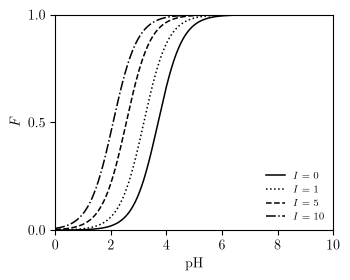

half-deprotonation pH, pK = 3.7:
   I =  0.0   pH = 3.700
   I =  1.0   pH = 3.188
   I =  5.0   pH = 2.556
   I = 10.0   pH = 2.082


In [3]:
fig, ax = plt.subplots(figsize=(3.6, 2.9))
styles = ["-", ":", "--", "-."]

for I, ls in zip(IONIC, styles):
    ax.plot(pH, fraction_deprotonated(pH, PK_BT, I, "thermodynamic"),
            ls, color="k", lw=1.1, label=fr"$I = {I:g}$")

ax.set_xlabel("pH"); ax.set_ylabel(r"$F$")
ax.set_xlim(0, 10); ax.set_ylim(0, 1)
ax.set_yticks([0, 0.5, 1.0])
ax.legend(frameon=False, fontsize=7, loc="lower right")
fig.tight_layout(); plt.show()

print("half-deprotonation pH, pK = 3.7:")
for I in IONIC:
    print(f"   I = {I:4.1f}   pH = {PK_BT - DEBYE_HUCKEL_LOG10 * np.sqrt(I):.3f}")


## The section computes the same answer a second way

A direction argued from a single equation can be wrong in sign without being wrong
anywhere a reader would see it, so Sec. 13.5 supplies an independent calculation ten pages
later. Illustration 13.5-6 solves for
the fractional dissociation $\alpha$ of 0.0001 M acetic acid with 0, 1 and 5 M NaCl
added, using the extended Debye-Huckel law rather than the limiting law, and prints the
result in Table 13.5-2:

| $M_\mathrm{NaCl}$ | $\alpha$, Table 13.5-2 | `thermo.ionization` |
|---|---|---|
| 0 | 0.339 | 0.3408 |
| 1 | 0.520 | 0.5203 |
| 5 | 0.597 | 0.5971 |

$\alpha$ goes **up** with added salt. More dissociation means the acid is apparently
stronger, so its apparent p$K$ is **lower** and the deprotonation curve moves **left** --
the same direction the curves above move, reached from a different equation, a different
acid and a different activity-coefficient model.

The shift in Fig. 13.5-1 and the $\alpha$ column of Table 13.5-2 are the same physics, so
a sign error in either one shows up as a disagreement between them.


## The deliverable art

`Figure_13.5-1.pdf`, written at the book's figure size in Computer Modern, pure black ink. Note what the redraw commits to: the curves shift **left** with added salt, which is the
direction argued in the cell above and confirmed independently by the $\alpha$ column of
Table 13.5-2. The half-points are 3.70, 3.19, 2.56 and 2.08 at $I = 0$, 1, 5 and 10, and
the printed axis range (pH 0 to 10) is kept.


In [4]:
os.makedirs("pdf", exist_ok=True)
path = "pdf/Figure_13.5-1.pdf"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"  wrote {path}")
print(f"\n  typography: {'LaTeX' if plt.rcParams['text.usetex'] else 'mathtext'}"
      f" Computer Modern")


  wrote pdf/Figure_13.5-1.pdf

  typography: LaTeX Computer Modern


## Your turn

1. The figure's four ionic strengths are 0, 1, 5 and 10 molal. A 10-molal NaCl solution
   is above saturation (about 6.1 molal at 25 C). Redraw the figure over an ionic-strength
   range a salt can actually reach, and say whether the shift is still visible.
2. The limiting law is used here at $I = 10$, where it is worthless. Redo the correct
   curve with the extended form printed after Fig. 13.5-1,
   $\ln\gamma_\pm=-1.178\sqrt I/(1+A\sqrt I)$ with $A = 1$, and compare the half-points.
   Which direction does the extended law move them, and by how much less?
3. Aspirin has p$K_a$ = 3.5 and is absorbed through the stomach lining only in its neutral
   form. Compute the neutral fraction at stomach pH (about 2) and at blood pH (7.4), and
   explain the ratio.
4. Problem 13.60 asks for Illustration 13.5-2 redone with solution nonidealities included.
   Do it, and then say which of the two effects -- the shift in the equilibrium or the
   shift in the definition of pH -- is the larger.
5. Take the correct expression and show analytically that
   $\mathrm{d}\,\mathrm{pH}_{1/2}/\mathrm{d}\sqrt I = -0.5116$ for a 1:1 acid. Then repeat
   for an acid that ionizes to a *divalent* anion, and predict whether the shift is
   larger or smaller before you compute it.
